## ---------- Average road distance between stations ----------


In [5]:
from pathlib import Path
import sys
import math

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
import matplotlib.dates as mdates


# ---------- Project path ----------
PROJECT_ROOT = Path("/Users/artur/Studia/Rowerki")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


# ---------- Plot style ----------
from plot_style import apply_montserrat_style

apply_montserrat_style()

In [6]:
def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    for path in [current, *current.parents]:
        if (path / "Data").exists():
            return path
    raise FileNotFoundError("Could not find project root containing Data/")


PROJECT_ROOT = find_project_root()
BASE_DIR = PROJECT_ROOT
DATA_DIR = PROJECT_ROOT / "Data"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


DATA_FILE = DATA_DIR / "final_trip_data.parquet"
ROAD_DISTANCE_DIR = DATA_DIR / "osm_route_cache" / "road_distances"
ROAD_DISTANCE_DIR.mkdir(parents=True, exist_ok=True)

ROAD_GRAPH_FILE = ROAD_DISTANCE_DIR / "london_bike_network.graphml"
STATION_NODES_FILE = ROAD_DISTANCE_DIR / "station_nearest_nodes.parquet"
PAIR_ROAD_DISTANCES_FILE = DATA_DIR / "station_pair_road_distances.parquet"

final_trip_data = pd.read_parquet(DATA_FILE)


def station_table_from_trips(trip_data):
    start_stations = trip_data[["start_station_name", "start_lat", "start_lon"]].rename(columns={
        "start_station_name": "station_name",
        "start_lat": "lat",
        "start_lon": "lon",
    })
    end_stations = trip_data[["end_station_name", "end_lat", "end_lon"]].rename(columns={
        "end_station_name": "station_name",
        "end_lat": "lat",
        "end_lon": "lon",
    })

    stations = pd.concat([start_stations, end_stations], ignore_index=True).dropna()
    stations["lat"] = stations["lat"].astype(float)
    stations["lon"] = stations["lon"].astype(float)
    return stations.groupby("station_name", as_index=False).agg(lat=("lat", "mean"), lon=("lon", "mean"))


def bbox_around_station_table(stations_table, buffer_meters=1200):
    mean_lat = math.radians(stations_table["lat"].mean())
    lat_margin = buffer_meters / 111_320
    lon_margin = buffer_meters / (111_320 * max(math.cos(mean_lat), 0.1))

    left = stations_table["lon"].min() - lon_margin
    bottom = stations_table["lat"].min() - lat_margin
    right = stations_table["lon"].max() + lon_margin
    top = stations_table["lat"].max() + lat_margin
    return left, bottom, right, top


def graph_covers_station_table(graph, stations_table, margin_degrees=0.002):
    node_lons = [float(data["x"]) for _, data in graph.nodes(data=True)]
    node_lats = [float(data["y"]) for _, data in graph.nodes(data=True)]

    return (
        min(node_lons) <= stations_table["lon"].min() - margin_degrees
        and max(node_lons) >= stations_table["lon"].max() + margin_degrees
        and min(node_lats) <= stations_table["lat"].min() - margin_degrees
        and max(node_lats) >= stations_table["lat"].max() + margin_degrees
    )


def nearest_graph_nodes_without_optional_dependencies(graph, stations_table):
    try:
        return ox.distance.nearest_nodes(
            graph,
            stations_table["lon"].to_numpy(),
            stations_table["lat"].to_numpy(),
        )
    except ImportError as error:
        print("OSMnx nearest_nodes needs an optional package in this environment:", error)
        print("Using a simple fallback nearest-node search instead.")

    graph_nodes = [
        (node, float(data["x"]), float(data["y"]))
        for node, data in graph.nodes(data=True)
    ]

    nearest_nodes = []
    for station in stations_table.itertuples(index=False):
        station_lon = float(station.lon)
        station_lat = float(station.lat)
        nearest_node = min(
            graph_nodes,
            key=lambda item: (item[1] - station_lon) ** 2 + (item[2] - station_lat) ** 2,
        )[0]
        nearest_nodes.append(nearest_node)

    return nearest_nodes


In [7]:
station_coordinates = station_table_from_trips(final_trip_data)
print("Stations with coordinates:", len(station_coordinates))

if ROAD_GRAPH_FILE.exists():
    print("Loading cached road graph:", ROAD_GRAPH_FILE)
    road_graph = ox.load_graphml(ROAD_GRAPH_FILE)
else:
    road_graph = None
    existing_graph_paths = sorted(
        (DATA_DIR / "osm_route_cache").glob("london_bike_graph_*.graphml"),
        key=lambda graph_path: graph_path.stat().st_size,
        reverse=True,
    )

    for graph_path in existing_graph_paths:
        candidate_graph = ox.load_graphml(graph_path)
        if graph_covers_station_table(candidate_graph, station_coordinates):
            print("Reusing existing graph cache:", graph_path)
            road_graph = candidate_graph
            ox.save_graphml(road_graph, ROAD_GRAPH_FILE)
            break

    if road_graph is None:
        print("Downloading London bike network for road-distance statistics...")
        ox.settings.use_cache = True
        ox.settings.cache_folder = str(DATA_DIR / "osm_route_cache" / "http_cache")
        ox.settings.log_console = False

        road_bbox = bbox_around_station_table(station_coordinates, buffer_meters=1200)
        try:
            road_graph = ox.graph_from_bbox(
                road_bbox,
                network_type="bike",
                simplify=True,
                retain_all=False,
                truncate_by_edge=True,
            )
        except TypeError:
            left, bottom, right, top = road_bbox
            road_graph = ox.graph_from_bbox(
                top,
                bottom,
                right,
                left,
                network_type="bike",
                simplify=True,
                retain_all=False,
                truncate_by_edge=True,
            )
        ox.save_graphml(road_graph, ROAD_GRAPH_FILE)
        print("Saved road graph:", ROAD_GRAPH_FILE)

if STATION_NODES_FILE.exists():
    station_nodes_df = pd.read_parquet(STATION_NODES_FILE)
else:
    nearest_nodes = nearest_graph_nodes_without_optional_dependencies(
        road_graph,
        station_coordinates,
    )
    station_nodes_df = station_coordinates.copy()
    station_nodes_df["nearest_node"] = nearest_nodes
    station_nodes_df.to_parquet(STATION_NODES_FILE, index=False)

station_nodes_df.head()


Stations with coordinates: 801
Loading cached road graph: /Users/artur/Studia/Rowerki/Data/osm_route_cache/road_distances/london_bike_network.graphml


,station_name,lat,lon,nearest_node
0,"Abbey Orchard Street, Westminster",51.498126,-0.132102,25378075
1,"Abbotsbury Road, Holland Park",51.501391,-0.205991,7416302958
2,"Aberdeen Place, St. John's Wood",51.524826,-0.176268,614477396
3,"Aberfeldy Street, Poplar",51.513548,-0.005659,259093586
4,"Abingdon Green, Westminster",51.497640,-0.125972,25534085


In [8]:
station_pair_counts = (
    final_trip_data
    .groupby(["start_station_name", "end_station_name"])
    .size()
    .reset_index(name="trip_count")
)

same_station_pairs = station_pair_counts[
    station_pair_counts["start_station_name"] == station_pair_counts["end_station_name"]
]
same_station_trip_count = int(same_station_pairs["trip_count"].sum())

station_pair_counts = station_pair_counts[
    station_pair_counts["start_station_name"] != station_pair_counts["end_station_name"]
].copy()

station_node_lookup = station_nodes_df.set_index("station_name")["nearest_node"].to_dict()
station_pair_counts["start_node"] = station_pair_counts["start_station_name"].map(station_node_lookup)
station_pair_counts["end_node"] = station_pair_counts["end_station_name"].map(station_node_lookup)
station_pair_counts = station_pair_counts.dropna(subset=["start_node", "end_node"]).copy()

print("Observed non-loop station pairs:", len(station_pair_counts))
print("Trips start=end excluded from road-distance mean:", same_station_trip_count)


Observed non-loop station pairs: 498947
Trips start=end excluded from road-distance mean: 620282


In [9]:
if PAIR_ROAD_DISTANCES_FILE.exists():
    station_pair_road_distances = pd.read_parquet(PAIR_ROAD_DISTANCES_FILE)
else:
    # Uzywamy grafu nieskierowanego, zeby statystyka mierzyla realna dlugosc po drogach,
    # bez tracenia par przez ograniczenia jednokierunkowosci w danych OSM.
    try:
        routing_graph = ox.convert.to_undirected(road_graph)
    except AttributeError:
        routing_graph = road_graph.to_undirected()

    rows = []
    grouped_pairs = station_pair_counts.groupby("start_station_name", sort=False)

    for source_index, (start_name, group) in enumerate(grouped_pairs, start=1):
        start_node = group["start_node"].iloc[0]
        path_lengths = nx.single_source_dijkstra_path_length(
            routing_graph,
            start_node,
            weight="length",
        )

        for row in group.itertuples(index=False):
            distance_m = path_lengths.get(row.end_node)
            if distance_m is None:
                continue

            rows.append({
                "start_station_name": row.start_station_name,
                "end_station_name": row.end_station_name,
                "trip_count": int(row.trip_count),
                "road_distance_m": float(distance_m),
                "road_distance_km": float(distance_m) / 1000,
            })

        if source_index % 50 == 0:
            print(f"Processed {source_index}/{len(grouped_pairs)} start stations")

    station_pair_road_distances = pd.DataFrame(rows)
    station_pair_road_distances.to_parquet(PAIR_ROAD_DISTANCES_FILE, index=False)

print("Pairs with road distance:", len(station_pair_road_distances))
station_pair_road_distances.head()


Pairs with road distance: 498947


,start_station_name,end_station_name,trip_count,road_distance_m,road_distance_km
0,"Abbey Orchard Street, Westminster","Aberdeen Place, St. John's Wood",1,4970.818341,4.970818
1,"Abbey Orchard Street, Westminster","Aberfeldy Street, Poplar",1,10574.545833,10.574546
2,"Abbey Orchard Street, Westminster","Abingdon Green, Westminster",46,593.672004,0.593672
3,"Abbey Orchard Street, Westminster","Abingdon Villas, Kensington",13,5107.068982,5.107069
4,"Abbey Orchard Street, Westminster","Ackroyd Drive, Bow",1,8880.344561,8.880345


In [10]:
mean_unique_road_km = station_pair_road_distances["road_distance_km"].mean()
mean_trip_weighted_road_km = (
    station_pair_road_distances["road_distance_km"] * station_pair_road_distances["trip_count"]
).sum() / station_pair_road_distances["trip_count"].sum()

covered_trip_count = int(station_pair_road_distances["trip_count"].sum())
expected_trip_count = int(station_pair_counts["trip_count"].sum())

road_distance_summary = pd.DataFrame([
    {
        "metric": "mean_unique_station_pair_road_km",
        "value": mean_unique_road_km,
    },
    {
        "metric": "mean_trip_weighted_road_km",
        "value": mean_trip_weighted_road_km,
    },
    {
        "metric": "covered_non_loop_trips",
        "value": covered_trip_count,
    },
    {
        "metric": "expected_non_loop_trips",
        "value": expected_trip_count,
    },
    {
        "metric": "excluded_same_station_trips",
        "value": same_station_trip_count,
    },
])

print(f"Mean road distance across unique station pairs: {mean_unique_road_km:.2f} km")
print(f"Mean road distance weighted by trips: {mean_trip_weighted_road_km:.2f} km")
print(f"Coverage: {covered_trip_count / expected_trip_count:.1%} of non-loop trips")

road_distance_summary


Mean road distance across unique station pairs: 5.30 km
Mean road distance weighted by trips: 2.95 km
Coverage: 100.0% of non-loop trips


,metric,value
0,mean_unique_station_pair_road_km,5.297812e+00
1,mean_trip_weighted_road_km,2.945890e+00
2,covered_non_loop_trips,1.680601e+07
3,expected_non_loop_trips,1.680601e+07
4,excluded_same_station_trips,6.202820e+05


In [11]:
station_name = "Waterloo Station 3, Waterloo"
station_name_clean = station_name.split(",")[0]

departures = final_trip_data.loc[
    final_trip_data["start_station_name"] == station_name,
    ["start_date"]
].copy()

departures = departures.rename(columns={"start_date": "date"})
departures["change"] = -1


arrivals = final_trip_data.loc[
    final_trip_data["end_station_name"] == station_name,
    ["end_date"]
].copy()

arrivals = arrivals.rename(columns={"end_date": "date"})
arrivals["change"] = 1


station_events = pd.concat([departures, arrivals])
station_events = station_events.sort_values("date")


station_events = station_events[
    (station_events["date"] >= "2024-01-01") &
    (station_events["date"] < "2026-01-01")
].copy()

station_events = station_events.sort_values("date")

station_events["balance"] = station_events["change"].cumsum()
station_events["balance"] = station_events["balance"].shift(fill_value=0)

station_events.head()

,date,change,balance
7991421,2024-01-01 08:02:00,1,0
7991219,2024-01-01 09:18:00,1,1
7991154,2024-01-01 09:39:00,1,2
7991150,2024-01-01 09:39:00,1,3
7991245,2024-01-01 10:43:00,1,4


In [12]:
station_events = station_events[
    (station_events["date"] >= "2024-01-01") &
    (station_events["date"] < "2026-01-01")
].copy()

station_events = station_events.sort_values("date")

station_events["balance"] = station_events["change"].cumsum()
station_events["balance"] = station_events["balance"].shift(fill_value=0)

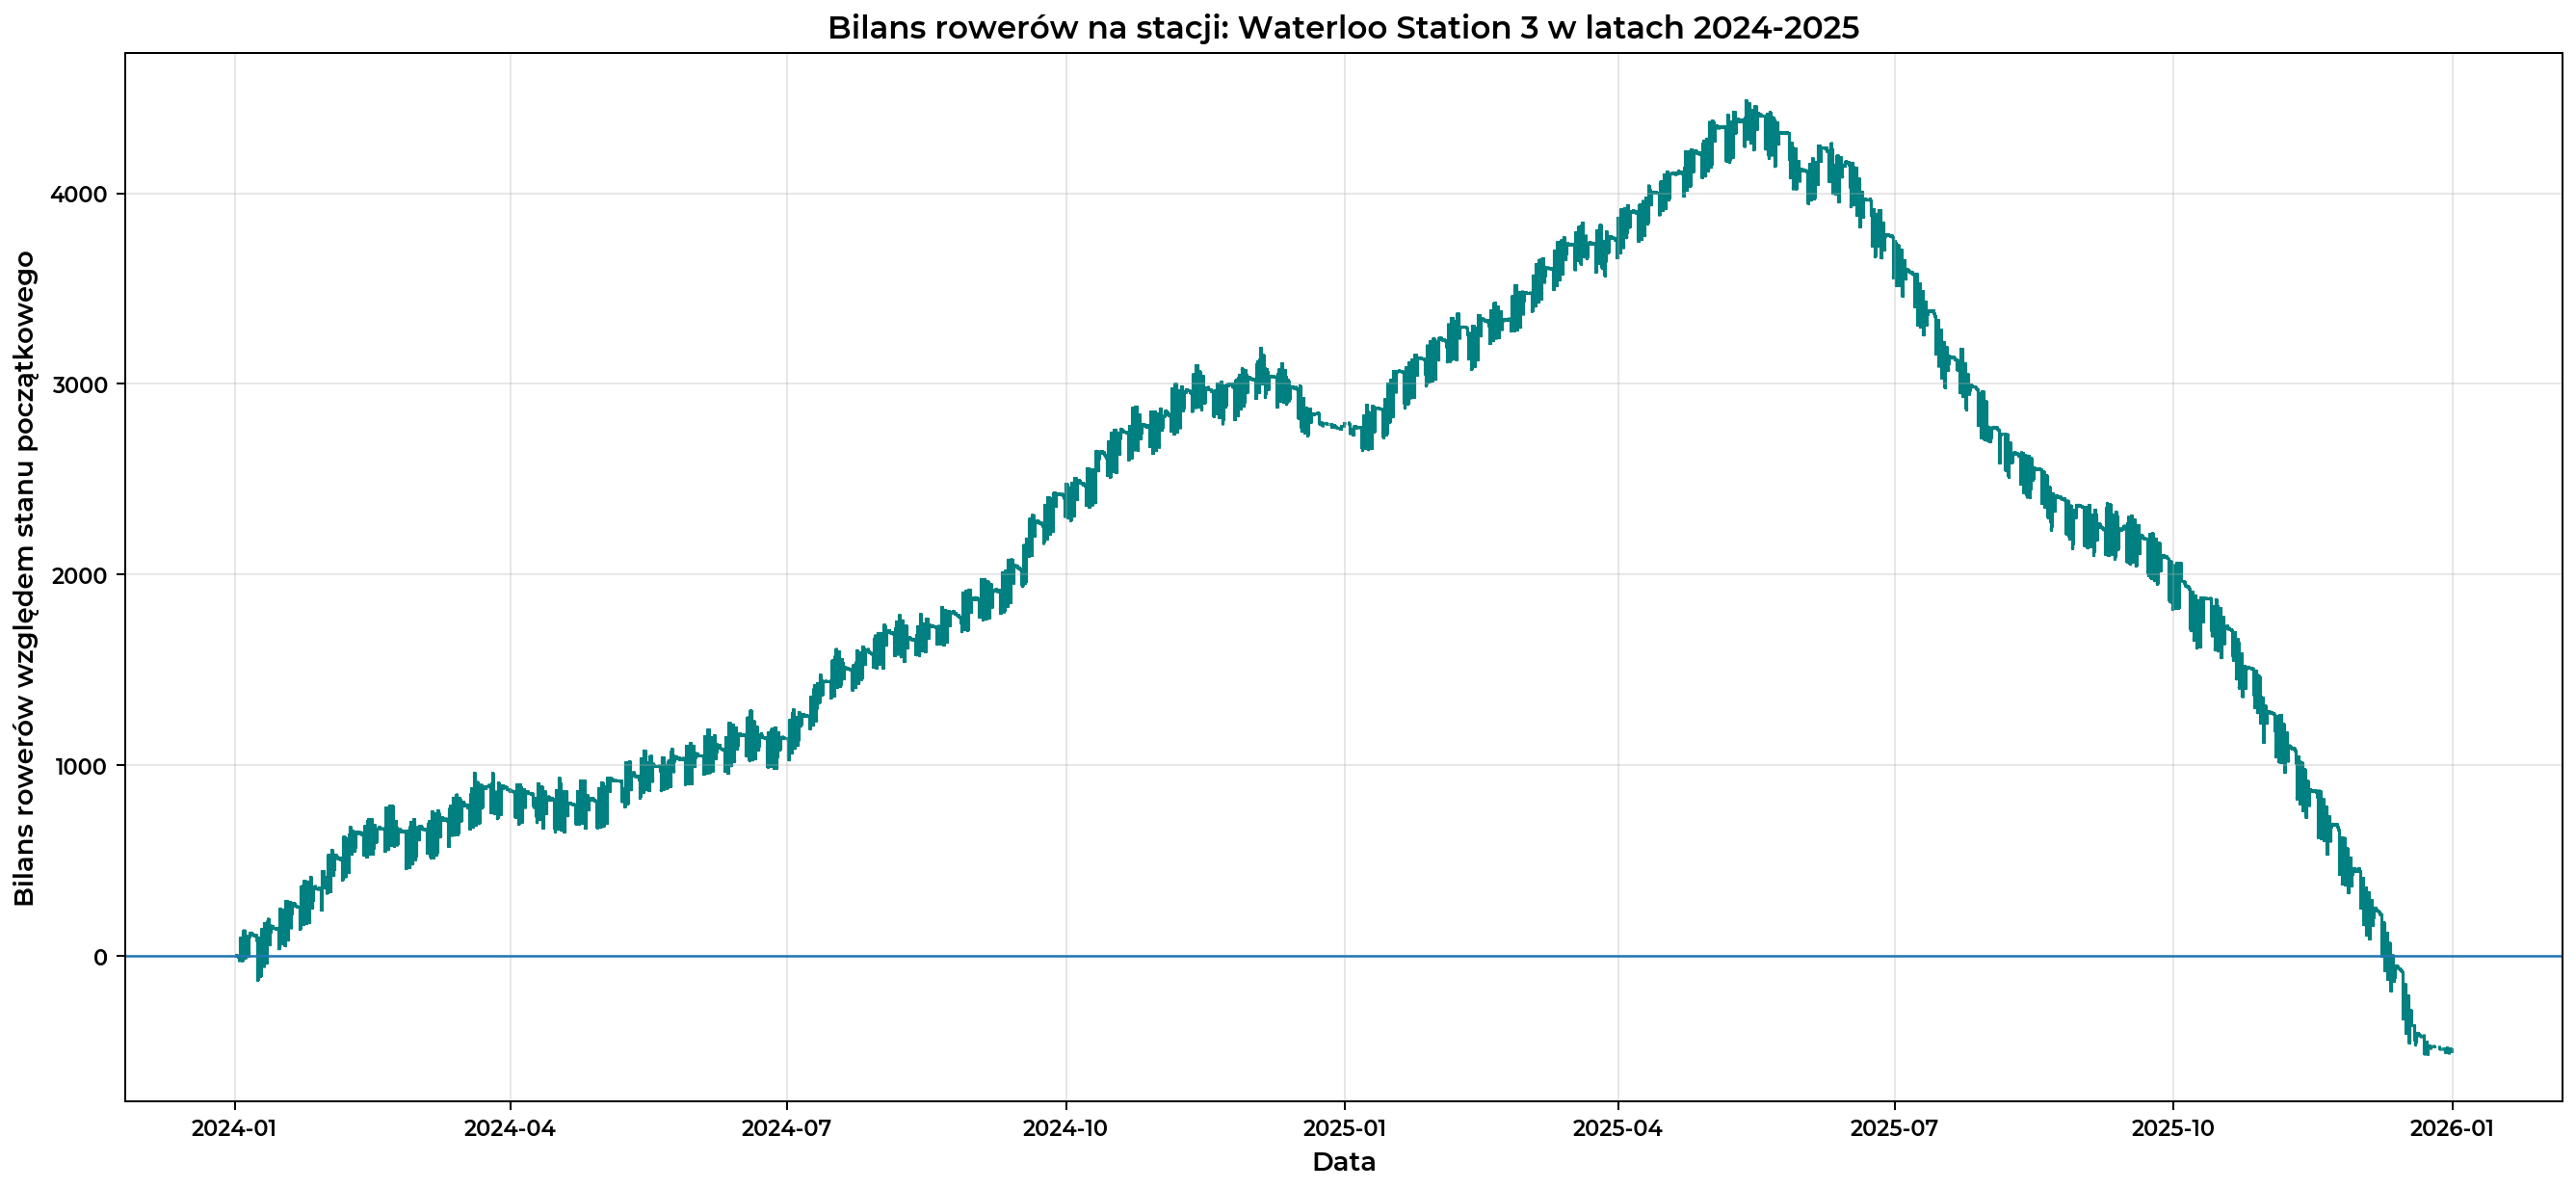

In [13]:
plt.figure(figsize=(15, 7))

plt.scatter(
    station_events["date"],
    station_events["balance"],
    s=0.05,
    color="teal"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Data")
plt.ylabel("Bilans rowerów względem stanu początkowego")
plt.title(f"Bilans rowerów na stacji: {station_name_clean} w latach 2024-2025")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
selected_weekdays = ["2025-08-18", "2025-08-19"]
selected_weekend = ["2025-08-23", "2025-08-24"]

start_weekday = pd.to_datetime(selected_weekdays[0])
end_weekday = pd.to_datetime(selected_weekdays[-1])

date_label = f"{start_weekday.day}-{end_weekday.day} sierpnia 2025"

selected_dates = [pd.to_datetime(day).date() for day in selected_weekdays]

few_day_events = station_events[
    station_events["date"].dt.date.isin(selected_dates)
].copy()

few_day_events = few_day_events.sort_values("date")

few_day_events["balance"] = few_day_events["change"].cumsum()
print(few_day_events["date"].min())
print(few_day_events["date"].max())

2025-08-18 05:17:00
2025-08-19 23:59:00


In [15]:
few_day_events.groupby(few_day_events["date"].dt.date).agg(
    liczba_zdarzen=("date", "count"),
    pierwsze_zdarzenie=("date", "min"),
    ostatnie_zdarzenie=("date", "max")
)

,liczba_zdarzen,pierwsze_zdarzenie,ostatnie_zdarzenie
date,,,
2025-08-18,375,2025-08-18 05:17:00,2025-08-18 22:31:00
2025-08-19,410,2025-08-19 05:38:00,2025-08-19 23:59:00


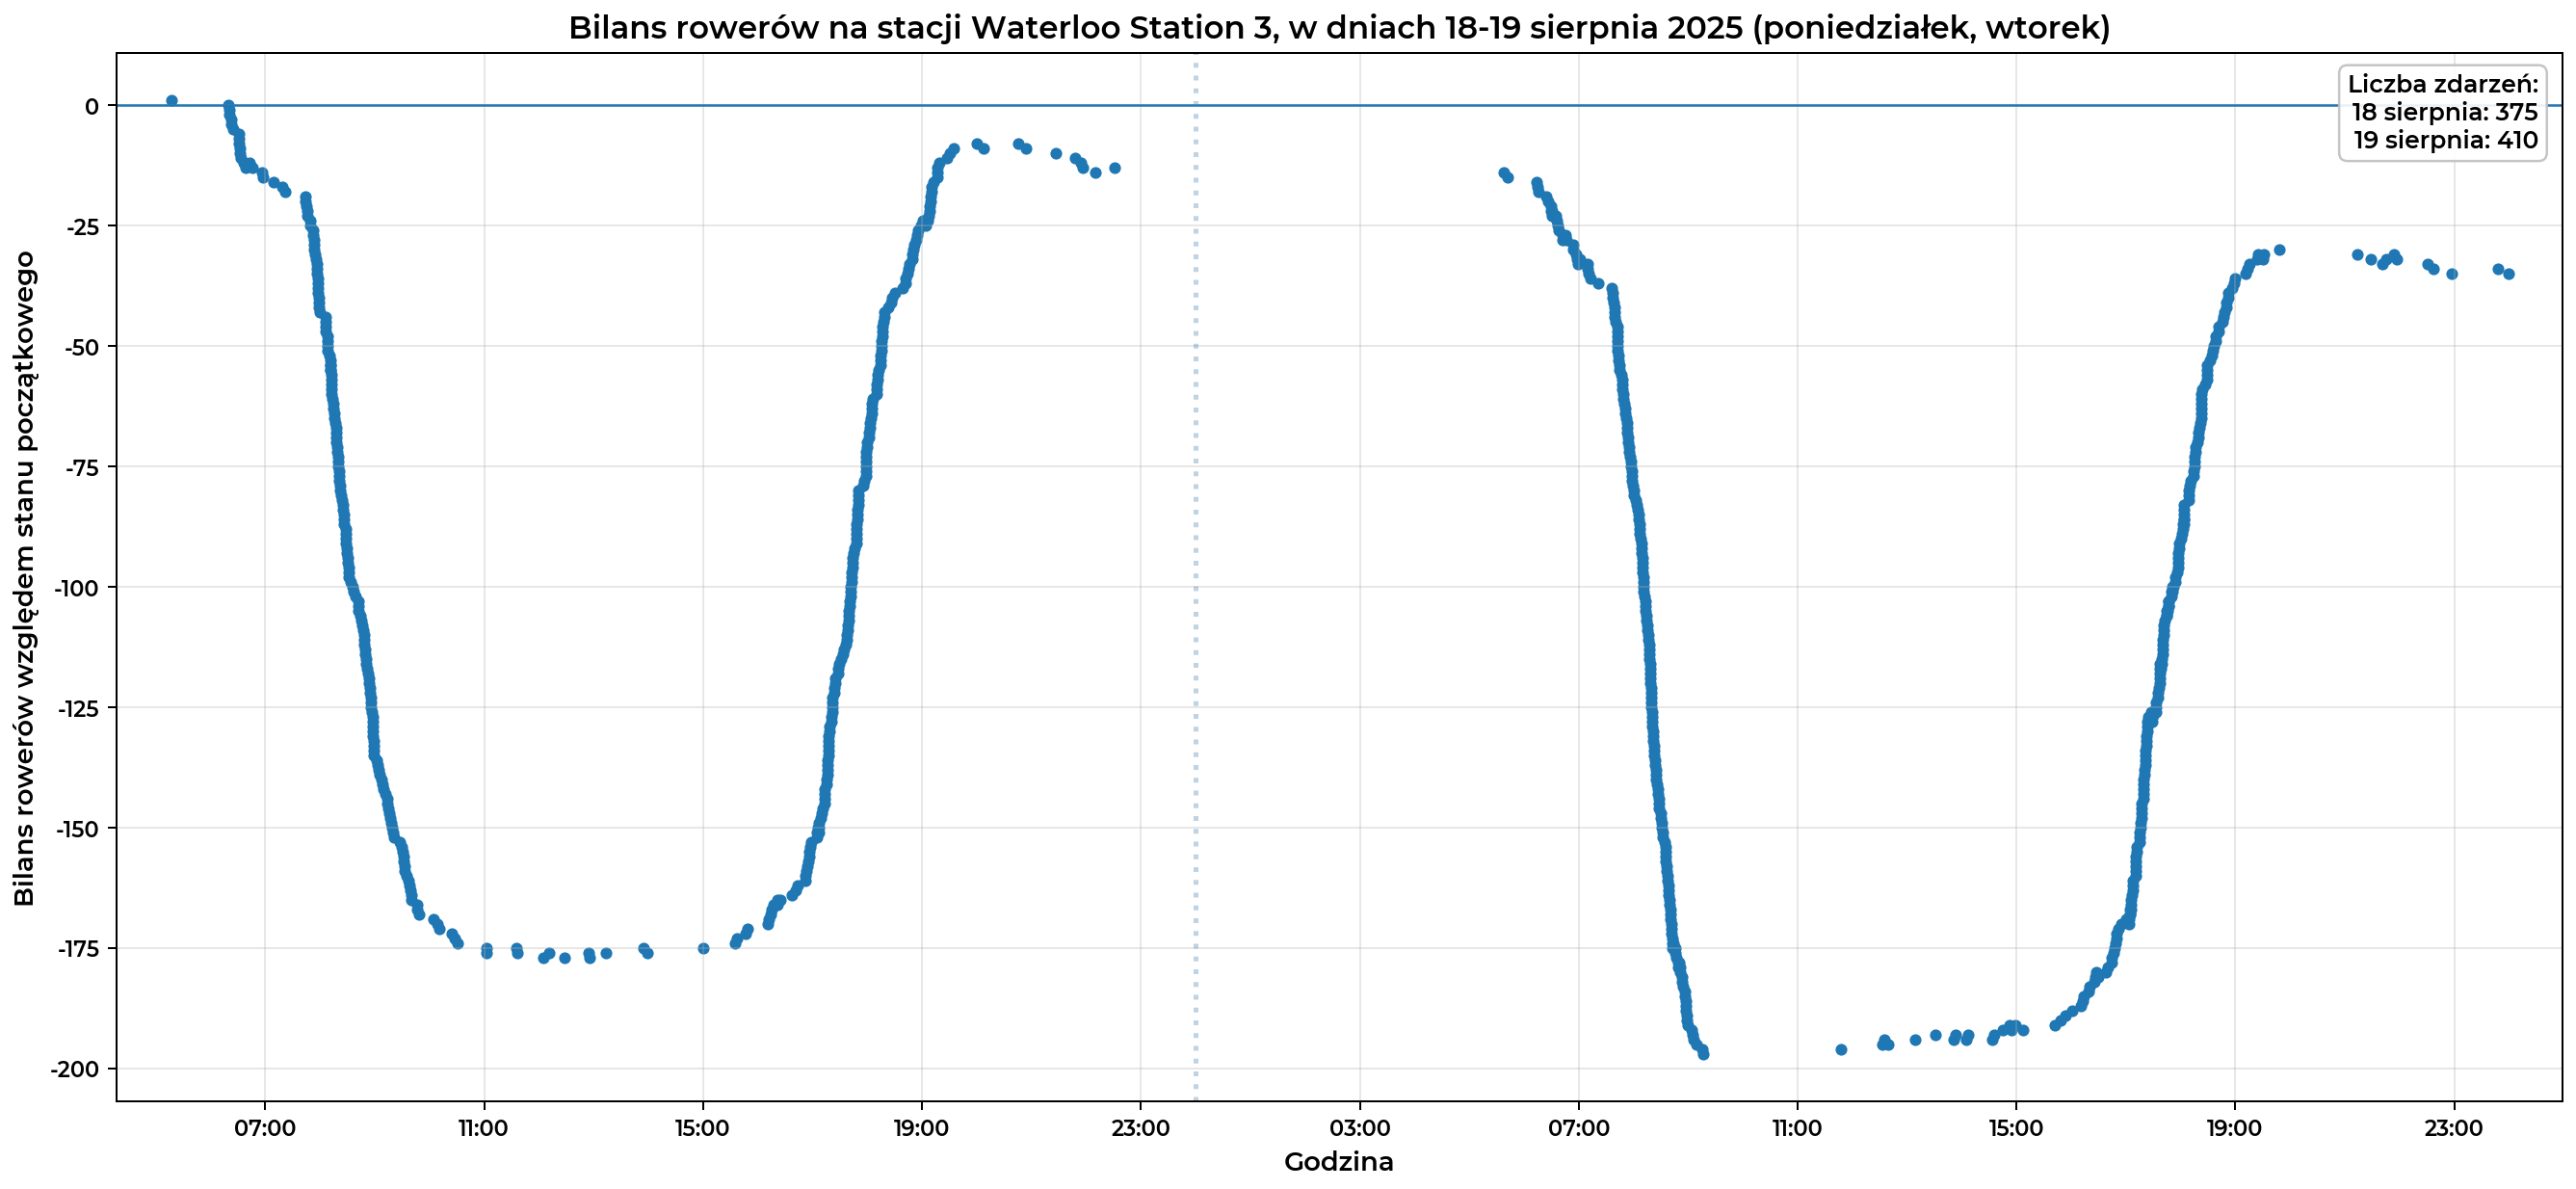

In [16]:
days_pl = {
    "Monday": "poniedziałek",
    "Tuesday": "wtorek",
    "Wednesday": "środa",
    "Thursday": "czwartek",
    "Friday": "piątek",
    "Saturday": "sobota",
    "Sunday": "niedziela"
}

months_pl = {
    1: "stycznia",
    2: "lutego",
    3: "marca",
    4: "kwietnia",
    5: "maja",
    6: "czerwca",
    7: "lipca",
    8: "sierpnia",
    9: "września",
    10: "października",
    11: "listopada",
    12: "grudnia"
}

def format_day_month(day):
    date = pd.to_datetime(day)
    return f"{date.day} {months_pl[date.month]}"

weekdays_label = ", ".join(
    days_pl[pd.to_datetime(day).day_name()] for day in selected_weekdays
)


x_start = few_day_events["date"].min()
x_end = few_day_events["date"].max()

# północe dla wybranych dni
midnights = pd.to_datetime(selected_weekdays)

events_per_day = (
    few_day_events
    .groupby(few_day_events["date"].dt.date)
    .size()
)

events_legend_lines = [
    f"{format_day_month(day)}: "
    f"{int(events_per_day.get(pd.to_datetime(day).date(), 0))}"
    for day in selected_weekdays
]

plt.figure(figsize=(15, 7))

# wykres punktowy zamiast liniowego
plt.scatter(
    few_day_events["date"],
    few_day_events["balance"],
    s=15
)

plt.axhline(0, linewidth=1)
plt.xlim(x_start - pd.Timedelta(hours=1), x_end + pd.Timedelta(hours=1))

# pionowe linie oznaczające północ
for midnight in midnights:
    plt.axvline(
        midnight,
        linestyle=":",
        linewidth=2,
        alpha=0.35,
        color = "steelblue"
    )

ax = plt.gca()
ax.text(
    0.99,
    0.98,
    "Liczba zdarzeń:\n" + "\n".join(events_legend_lines),
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.75",
        alpha=0.9
    )
)

plt.xlabel("Godzina")
plt.ylabel("Bilans rowerów względem stanu początkowego")
plt.title(
    f"Bilans rowerów na stacji {station_name_clean}, "
    f"w dniach {date_label} ({weekdays_label})"
)

# godziny na osi X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=4))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
selected_weekend = ["2025-08-23", "2025-08-24"]

start_weekend = pd.to_datetime(selected_weekend[0])
end_weekend = pd.to_datetime(selected_weekend[-1])

date_label = f"{start_weekend.day}-{end_weekend.day} sierpnia 2025"

selected_dates = [pd.to_datetime(day).date() for day in selected_weekend]

weekend_events = station_events[
    station_events["date"].dt.date.isin(selected_dates)
].copy()

weekend_events = weekend_events.sort_values("date")

weekend_events["balance"] = weekend_events["change"].cumsum()

print(weekend_events["date"].min())
print(weekend_events["date"].max())

2025-08-23 00:01:00
2025-08-24 23:58:00


In [18]:
weekend_events.groupby(weekend_events["date"].dt.date).agg(
    liczba_zdarzen=("date", "count"),
    pierwsze_zdarzenie=("date", "min"),
    ostatnie_zdarzenie=("date", "max")
)

,liczba_zdarzen,pierwsze_zdarzenie,ostatnie_zdarzenie
date,,,
2025-08-23,41,2025-08-23 00:01:00,2025-08-23 23:24:00
2025-08-24,39,2025-08-24 00:13:00,2025-08-24 23:58:00


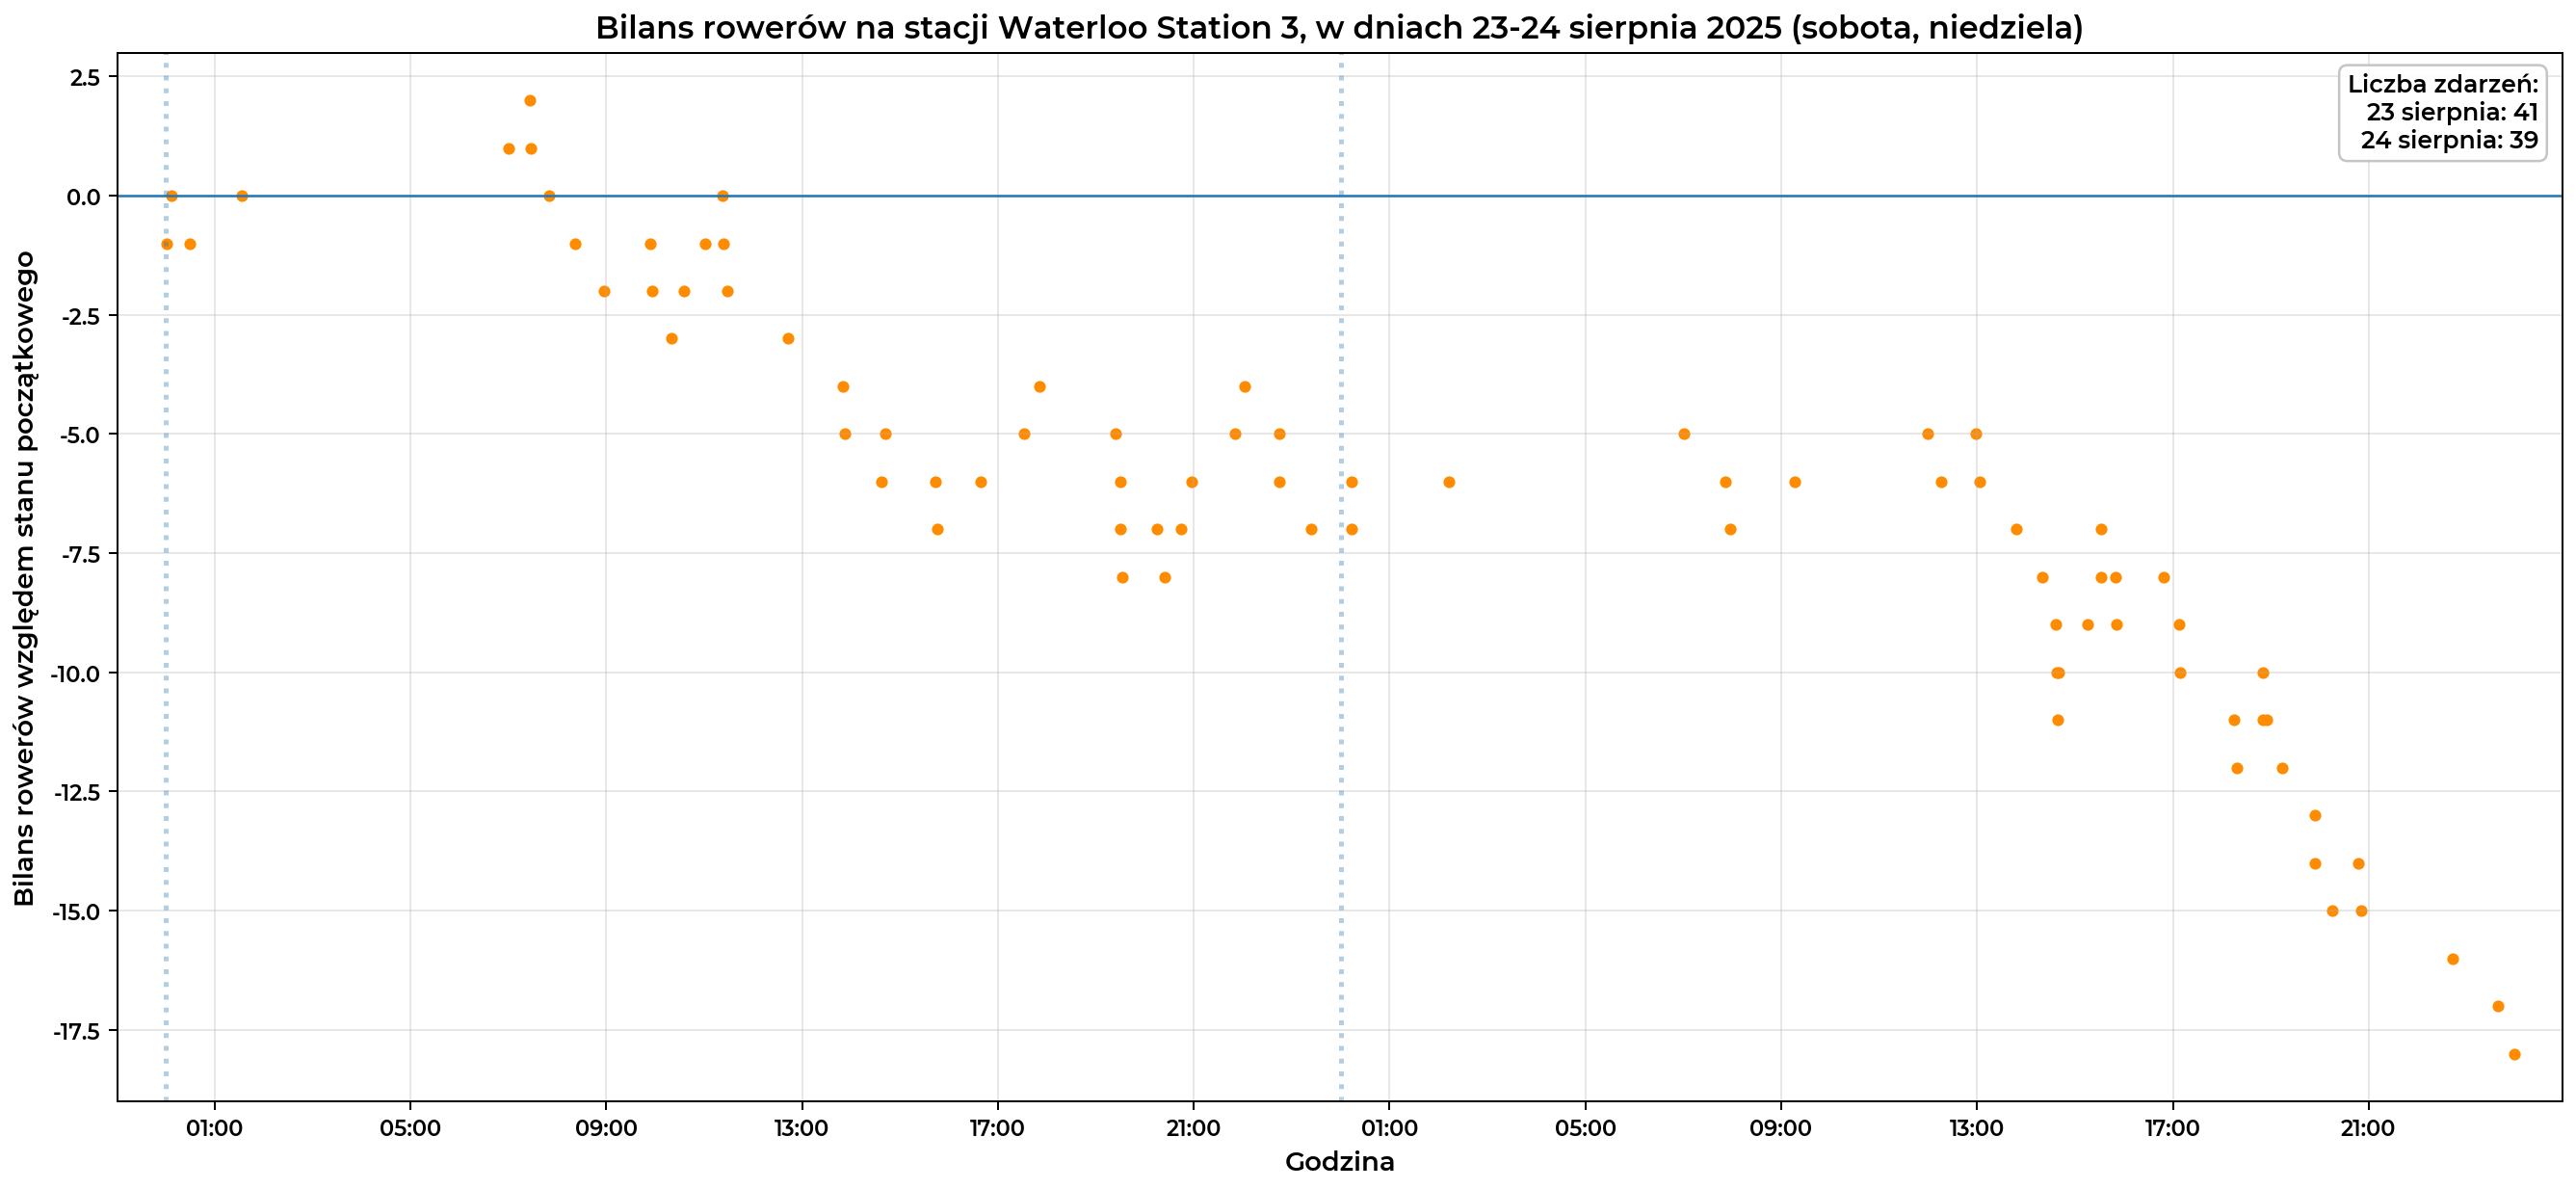

In [19]:
months_pl = {
    1: "stycznia",
    2: "lutego",
    3: "marca",
    4: "kwietnia",
    5: "maja",
    6: "czerwca",
    7: "lipca",
    8: "sierpnia",
    9: "września",
    10: "października",
    11: "listopada",
    12: "grudnia"
}

def format_day_month(day):
    date = pd.to_datetime(day)
    return f"{date.day} {months_pl[date.month]}"

weekend_label = ", ".join(
    days_pl[pd.to_datetime(day).day_name()] for day in selected_weekend
)

x_start = weekend_events["date"].min()
x_end = weekend_events["date"].max()

midnights = pd.to_datetime(selected_weekend)

events_per_day = (
    weekend_events
    .groupby(weekend_events["date"].dt.date)
    .size()
)

events_legend_lines = [
    f"{format_day_month(day)}: "
    f"{int(events_per_day.get(pd.to_datetime(day).date(), 0))}"
    for day in selected_weekend
]

plt.figure(figsize=(15, 7))

plt.scatter(
    weekend_events["date"],
    weekend_events["balance"],
    s=15,
    color="darkorange"
)

plt.axhline(0, linewidth=1)

plt.xlim(
    x_start - pd.Timedelta(hours=1),
    x_end + pd.Timedelta(hours=1)
)

for midnight in midnights:
    plt.axvline(
        midnight,
        linestyle=":",
        linewidth=2,
        alpha=0.35
    )

ax = plt.gca()
ax.text(
    0.99,
    0.98,
    "Liczba zdarzeń:\n" + "\n".join(events_legend_lines),
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.75",
        alpha=0.9
    )
)

plt.xlabel("Godzina")
plt.ylabel("Bilans rowerów względem stanu początkowego")
plt.title(
    f"Bilans rowerów na stacji {station_name_clean}, "
    f"w dniach {date_label} ({weekend_label})"
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=4))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# ---------- Station balance function ----------

def calculate_station_balance(final_trip_data, station_name, start_date="2024-01-01", end_date="2026-01-01"):

    departures = final_trip_data.loc[
        final_trip_data["start_station_name"] == station_name,
        ["start_date"]
    ].copy()

    departures = departures.rename(columns={"start_date": "date"})
    departures["change"] = -1


    arrivals = final_trip_data.loc[
        final_trip_data["end_station_name"] == station_name,
        ["end_date"]
    ].copy()

    arrivals = arrivals.rename(columns={"end_date": "date"})
    arrivals["change"] = 1


    station_events = pd.concat([departures, arrivals], ignore_index=True)

    station_events = station_events[
        (station_events["date"] >= start_date) &
        (station_events["date"] < end_date)
    ].copy()

    station_events = station_events.sort_values("date")

    station_events["balance"] = station_events["change"].cumsum()
    station_events["balance"] = station_events["balance"].shift(fill_value=0)

    return station_events

In [21]:
# ---------- Stations excluded because of active balancing ----------

excluded_station_keywords = [
    "Waterloo Station",
    "Queen Street",
    "Moorfields",
    "Holborn Circus",
    "Newgate Street",
    "St James's Square",
    "Imperial College",
    "St. George's Street",
    "Houndsditch",
    "Kingsway Southbound"
]


# ---------- Choosing second station automatically ----------

all_station_names = pd.concat(
    [
        final_trip_data["start_station_name"],
        final_trip_data["end_station_name"]
    ],
    ignore_index=True
).dropna()

station_counts = all_station_names.value_counts()

candidate_stations = station_counts[
    ~station_counts.index.to_series().apply(
        lambda name: any(excluded in name for excluded in excluded_station_keywords)
    )
]

second_station_name = candidate_stations.index[0]

print("Wybrana druga stacja:", second_station_name)

Wybrana druga stacja: Hyde Park Corner, Hyde Park


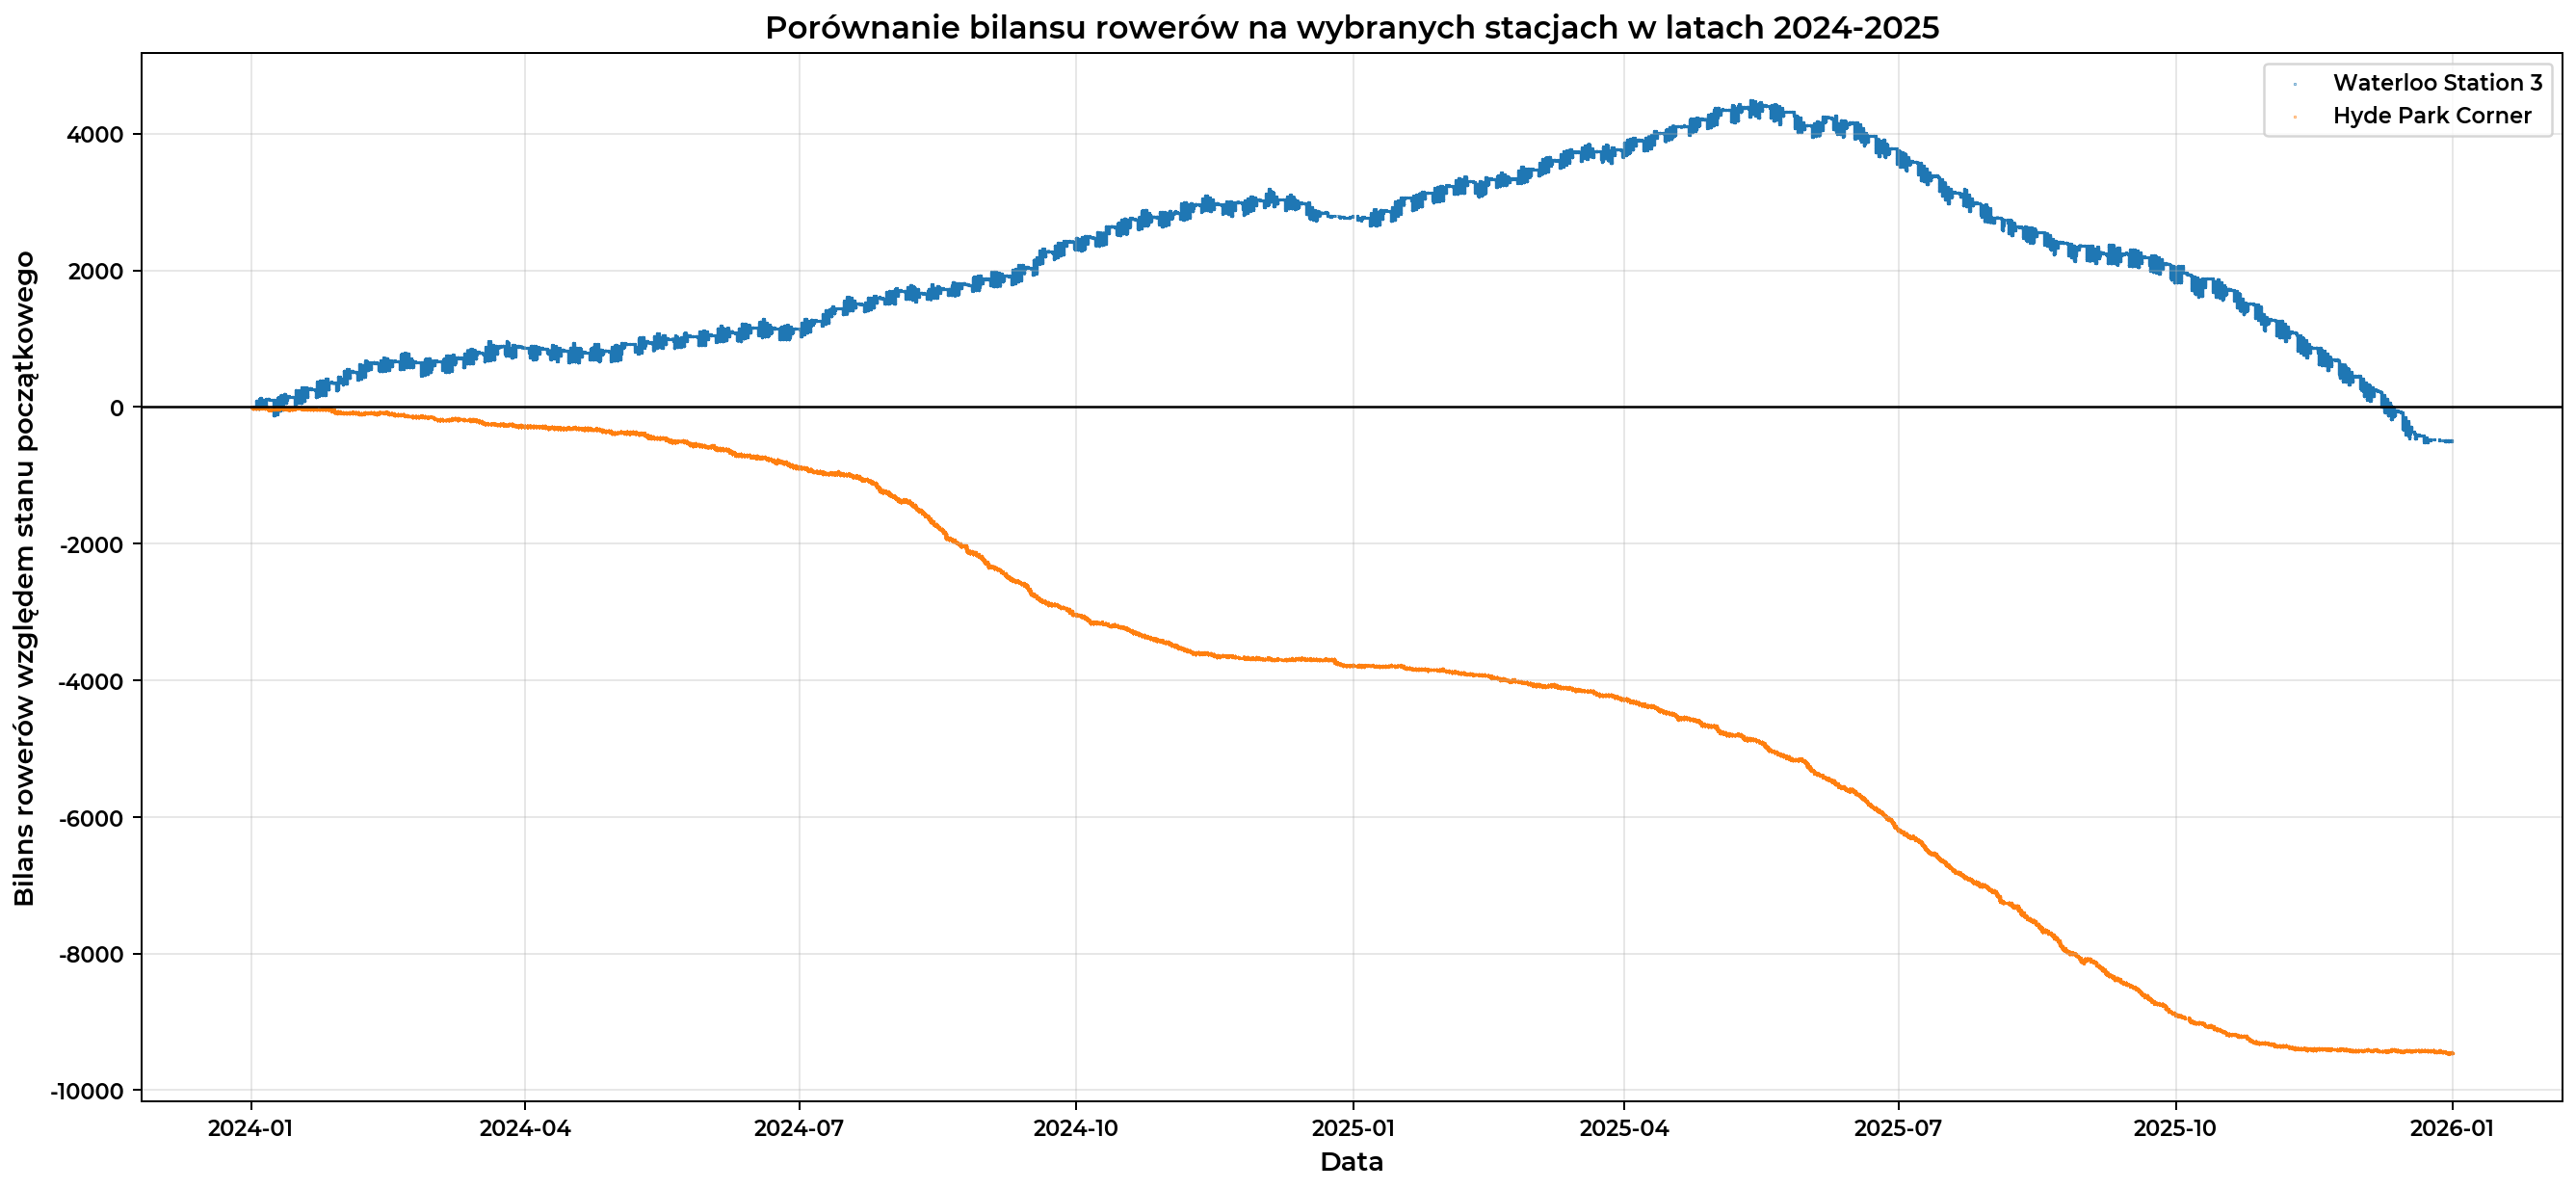

In [22]:
# ---------- Selected stations ----------

station_name_1 = "Waterloo Station 3, Waterloo"
station_name_2 = second_station_name

station_name_1_clean = station_name_1.split(",")[0]
station_name_2_clean = station_name_2.split(",")[0]


# ---------- Balance calculation ----------

station_events_1 = calculate_station_balance(final_trip_data, station_name_1)
station_events_2 = calculate_station_balance(final_trip_data, station_name_2)


# ---------- Plot ----------

plt.figure(figsize=(15, 7))

plt.scatter(
    station_events_1["date"],
    station_events_1["balance"],
    s=0.05,
    color="#1F77B4",
    label=station_name_1_clean
)

plt.scatter(
    station_events_2["date"],
    station_events_2["balance"],
    s=0.05,
    color="#FF7F0E",
    label=station_name_2_clean
)

plt.axhline(0, linewidth=1, color="black")

plt.xlabel("Data")
plt.ylabel("Bilans rowerów względem stanu początkowego")
plt.title("Porównanie bilansu rowerów na wybranych stacjach w latach 2024-2025")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()